# Artefact Reduction by Homogeneous Field Correction

This section explains how Homogeneous Field Correction (HFC) is used to attenuate artefacts in the OPM  data. Homogeneous Field Correction (HFC) is a preprocessing technique that suppresses artefacts that manifest as spatially uniform magnetic fields across the sensor array [1]. These artefacts are generated by sources in the environment that may come from electrical devices or moving magnetic objects. Examples are ventilation systems, belt buckles on the participant, elevators, driving cars, magnetic door latches, as well as vibrations. Another large contribution comes from movements in which the sensor array is moving within the recidual fields of the magnetically shielded room. These artefacts tend to generate magnetic fields that are fairly spatially homogenous as they are typically far away from the sensor array. Brain activity, on the other hand, produces magnetic fields which are less homogenous with higher spatial gradients as the fields are generated by neuronal sources with proximity to the sensors. 
The goal of HFC is to remove the component of the measured signal that is common across all sensors, assuming it arises from a spatially uniform (homogeneous) field. By applying HFC, the quality of the OPM data is improved, background noise is reduced, and the OPM system becomes more accurate in detecting and localizing the true magnetic sources from the brain activity.This section explains how HFC can be applied in MNE Python to attenuate artefacts in the OPM data. 

HFC operates by applying a linear projection applied to all the sensors. If there are sensors that are 'flat' or reflect excessive noise, they must be removed prior to the HFC procedure such that they do not contribute to spreading noise. Therefore, prior to applying HFC, it is important to identify and exclude 'bad' sensors. 

## Import the necessary modules
Below are the required Python modules to be imported for this section

In [75]:
import mne
import os
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import array
from pprint import pprint
import json
import os.path as op
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
    write_meg_calibration,
    write_meg_crosstalk,
    write_raw_bids,
)
from mne_bids.stats import count_events

## File overview

The chapter relies on the file (embedded in BIDS):
```
< BIDS_ROOT >/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_meg.fif
```
and generates the output file in the 'derivatives' folder of the BIDS 
```
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
```




## Loading the BIDS data

Specify the parameters allowing for defining the BIDS folder `data_path` which is dependent on where the data are stored locally.  

In [76]:
subject = '01'  
session = '01'  
task = 'SpAtt'
run = '01'  
meg_suffix = 'meg'
meg_extension = '.fif'
events_suffix = 'eve'
events_extension = '.tsv'

data_path = 'E:/Sub_003_Cerca/Experiment'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf2/Experiment'


bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=meg_suffix, extension=meg_extension, root=bids_root)

Create a 'derivative folder' where the processed data will be stored:

In [77]:
deriv_root = op.join(bids_root, 'derivatives/preprocessing')  # output path

deriv_path = BIDSPath(subject=subject, session=session, datatype='meg',
            task=task, run=run, suffix=meg_suffix, root=deriv_root).mkdir()

deriv_fname = bids_path.basename.replace('meg', 'hfc_raw') # output filename
deriv_file_1 = op.join(deriv_path.directory, deriv_fname)

Read the raw data

In [78]:
raw = read_raw_bids(bids_path=bids_path, verbose=False,extra_params={'preload':True})

## Idenfity the Faulty Sensors

The first step is to flag sensors as “bad” based on what we observed during acquisition. After the bad‐sensor list is further augmented by identifying outliers based on the power spectral density estimates. The sensors B4 and H6 happened to be faulty. 

In [79]:
ch_names = raw.info['ch_names']
bad_chs = ['B4', 'H6','A6']
bad_channels = [name for name in ch_names if any(ch in name for ch in bad_chs)]
raw.info['bads'] = bad_channels
raw.save
# Print the bad channels 
print("Bad channels marked:", raw.info['bads'])

Bad channels marked: ['F5 A6 Z', 'F5 A6 Y', 'F5 A6 X', 'T14 H6 Z', 'T14 H6 Y', 'T14 H6 X', 'AFz B4 Z', 'AFz B4 Y', 'AFz B4 X']


Now, additional noisy bad sensors will be identified based on the average power spectral density (PSD) of each sensor. Sensors with an average PSD value crossing a predefined threshold will be flagged as bad and hence  not contribute towards the HFC filtering. 

### Calculate and plot the PSDs

In [80]:
n_fft = 2000
picks = mne.pick_types(raw.info, meg=True,exclude='bads')
raw_PSD = raw.compute_psd(method="welch", fmin=0.1, fmax=120, picks=picks, n_fft=n_fft, n_overlap=int(n_fft/2))
psds = raw_PSD.get_data() # units are in T^2/Hz
freqs = raw_PSD.freqs 
psd_db = 10 * np.log10(psds * 1e30)# Ref power: 1fT^2=1e-30T^2
average_power = np.mean(psd_db, axis=1)

Effective window size : 2.667 (s)


To plot the result using the commands

Plotting power spectral density (dB=True).


/opt/miniconda3/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


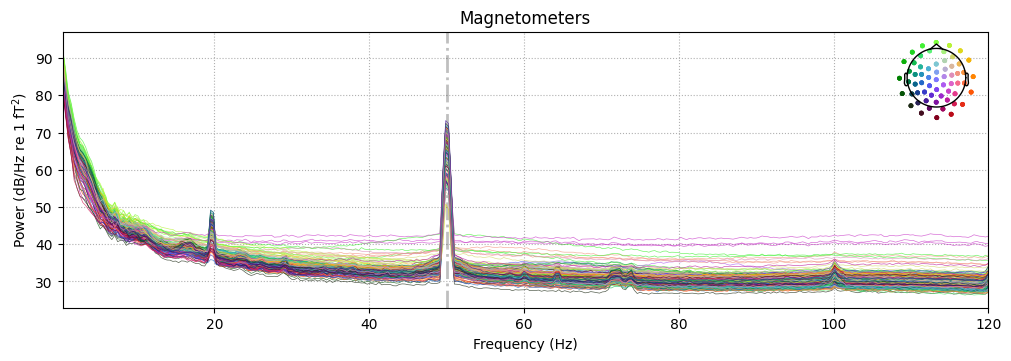

In [81]:
raw_PSD.plot();

### Histograms of sensor power
As a next step, histograms of the power averaged across freqeuncues will be plotted for the different sensors.

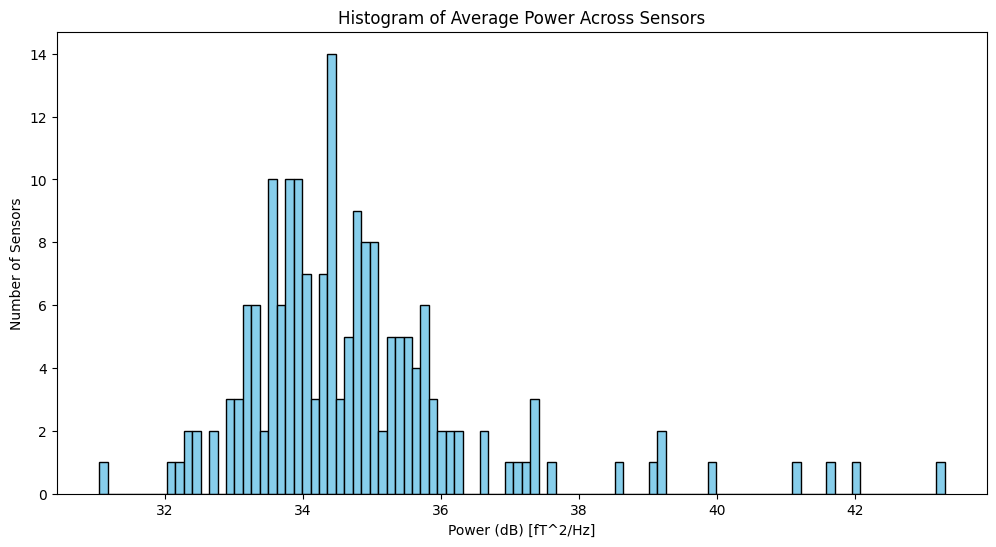

In [82]:
%matplotlib inline
plt.figure(figsize=(12, 6))
BNS = 100
plt.hist(average_power, bins=BNS,color='skyblue',edgecolor='black'); plt.xlabel('Power (dB) [fT^2/Hz]');plt.ylabel('Number of Sensors'); plt.title('Histogram of Average Power Across Sensors');

**Question 1:** Where are the noisy sensors located? Identify and mark the sensor on the layout below

**Question 2:** Plot the time course of a few noisy sensors and compare to non-noisy sensors. What characterizes the noisy sensors?

### Identifying and flagging sensors with high power
To identify the sensors above the threshold of 36.5 dB write

In [99]:
sensor_names = raw_PSD.ch_names
sensors_above_threshold = [sensor_names[i] for i, avg in enumerate(average_power) if avg > 36.5]
print(sensors_above_threshold)

['F7 C3 Z', 'F7 C3 Y', 'F7 C3 X', 'T7 C8 Y', 'F6 B8 X', 'F12 D8 X', 'C2 B5 Z', 'C2 B5 Y', 'P4 D3 X', 'P6 F2 Z', 'P6 F2 Y', 'P6 F2 X', 'O6 H1 Y', 'O6 H1 X', 'O8 H5 Z', 'T2 B2 X', 'Fz A5 Z', 'Iz H4 Y']


Flag the sensors above the threshold as bad with the data structure. This will be done by augmenting the existing list of bad sensors

In [100]:
raw.info['bads'].extend(sensors_above_threshold)
print(raw.info['bads'])


['F5 A6 Z', 'F5 A6 Y', 'F5 A6 X', 'T14 H6 Z', 'T14 H6 Y', 'T14 H6 X', 'AFz B4 Z', 'AFz B4 Y', 'AFz B4 X', 'F3 A3 Z', 'F3 A3 Y', 'F3 A3 X', 'T5 C5 Z', 'F4 B6 Z', 'F8 B1 Z', 'F8 B1 Y', 'F8 B1 X', 'C4 D7 X', 'C6 D4 Z', 'C6 D4 Y', 'C6 D4 X', 'P8 F1 Z', 'P8 F1 Y', 'P8 F1 X', 'O2 H3 Y', 'T4 D1 Z', 'Fpz A2 Y', 'F7 C3 Z', 'F7 C3 Y', 'F7 C3 X', 'T7 C8 Y', 'F6 B8 X', 'F12 D8 X', 'C2 B5 Z', 'C2 B5 Y', 'P4 D3 X', 'P6 F2 Z', 'P6 F2 Y', 'P6 F2 X', 'O6 H1 Y', 'O6 H1 X', 'O8 H5 Z', 'T2 B2 X', 'Fz A5 Z', 'Iz H4 Y']


## Applying Homogenous Field Correction

Before doing the HFC remove bad sensors and plot of the raw data before pre-processing

Text(0.5, 1.0, 'Before Applying HFC')

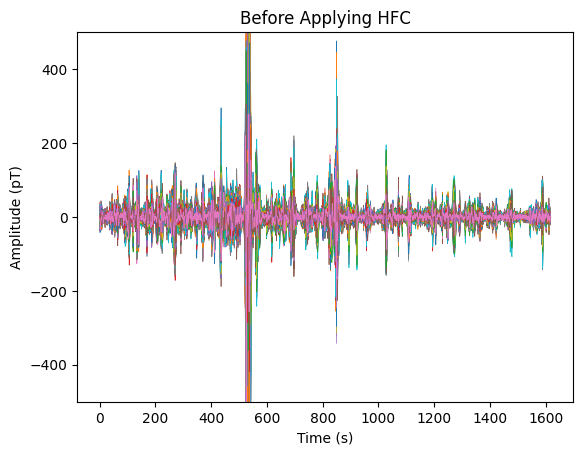

In [101]:
picks = mne.pick_types(raw.info, meg=True,exclude='bads')
rawRJ=raw.copy().pick(picks)

amp_scale = 1e12  # Converting to pico Tesla(pT)
stop = len(rawRJ.times)-300
step = 500
data_ds, time_ds = rawRJ[:, :stop]
data_ds, time_ds = data_ds[:, ::step]* amp_scale , time_ds[::step]

plt.plot(time_ds, data_ds.T - np.mean(data_ds, axis=1),lw=0.5);
plt.ylim(-500, 500)
plt.xlabel('Time (s)'); 
plt.ylabel('Amplitude (pT)')
#plt.xlim(time_ds[0], time_ds[-1])
#plt.grid(True)
plt.title("Before Applying HFC")

### Interference rejection using Homogeneous Field Correction

In [102]:
rawHFC=rawRJ.copy()
projs = mne.preprocessing.compute_proj_hfc(rawHFC.info, order=2)
rawHFC.add_proj(projs).apply_proj(verbose="error")

8 projection items deactivated


<Raw | sub-01_ses-01_task-SpAtt_run-01_meg.fif, 147 x 1213664 (1618.2 s), ~1.33 GiB, data loaded>

Plotting the raw data after applying HFC

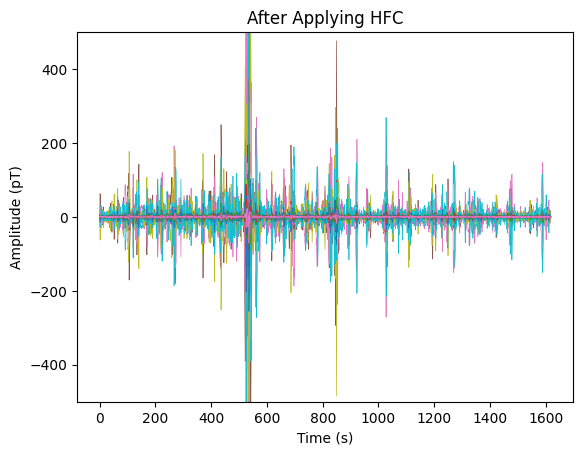

In [103]:

amp_scale = 1e12  # Converting to pico Tesla(pT)
stop = len(raw.times) - 300
step = 500
data_ds, time_ds = rawHFC[:, :stop]
data_ds, time_ds = data_ds[:, ::step]* amp_scale , time_ds[::step]

plt.plot(time_ds, data_ds.T - np.mean(data_ds, axis=1),lw=0.5);
plt.ylim(-500, 500);
plt.xlabel('Time (s)'); 
plt.ylabel('Amplitude (pT)')
#plt.xlim(time_ds[0], time_ds[-1])
#plt.grid(True)
plt.title("After Applying HFC")
plt.show()

The artifacts are now clearly reduced showing the utility of the HFC. These artifacts prior to the HFC were likely due to the participant moving within room and other sources. Despite the shielding, there will be recidual field remaining that procudes a signal when the sensors are moving within the recidual field.

The artifacts are now clearly reduced showing the utility of the HFC. These artifacts prior to the HFC were likely due to the participant moving within room. Despite the shielding, there will be recidual field remaining that procudes a signal when the sensors are moving within the recidual field.

### Powerspectra after HFC
Another way to inspect the effects of HFC is to consider the power-spectra

In [104]:
n_fft = 2000
raw_PSD = rawRJ.compute_psd(method="welch", fmin=0.1, fmax=120, picks="mag", n_fft=n_fft, n_overlap=int(n_fft/2))
psds = raw_PSD.get_data() # units are in T^2/Hz
freqs = raw_PSD.freqs 
psd_db = 10 * np.log10(psds * 1e30)# Ref power: 1fT^2=1e-30T^2

raw_PSDc = rawHFC.compute_psd(method="welch", fmin=0.1, fmax=120, picks='mag', n_fft=n_fft, n_overlap=int(n_fft/2))
psdsc = raw_PSDc.get_data() # units are in T^2/Hz
freqsc = raw_PSDc.freqs 
psd_dbc = 10 * np.log10(psdsc * 1e30)  # Ref power: 1fT^2=1e-30T^2   

Effective window size : 2.667 (s)
Effective window size : 2.667 (s)


For comparison, plot the spectra next to each other for no HFC and for HFC:

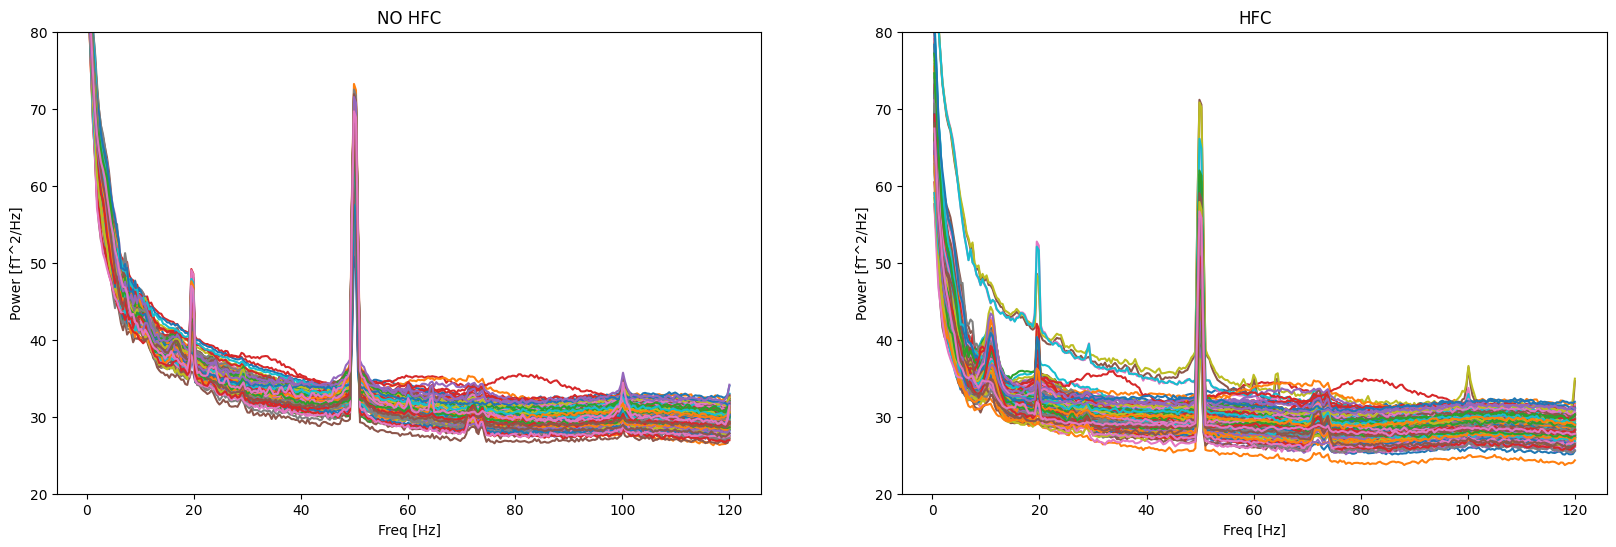

In [105]:
plt.figure(figsize=(20, 6))

plt.subplot(1,2,1)
plt.plot(freqs,psd_db.T);plt.ylim(20, 80);plt.xlabel('Freq [Hz]');plt.ylabel('Power [fT^2/Hz]');plt.title('NO HFC');

plt.subplot(1,2,2)
plt.plot(freqsc,psd_dbc.T);plt.ylim(20, 80);plt.xlabel('Freq [Hz]');plt.ylabel('Power [fT^2/Hz]');plt.title('HFC');

The power over a wide frequency range is reduced following HFC. This becomes more evident when considering the spectra averaged over sensors

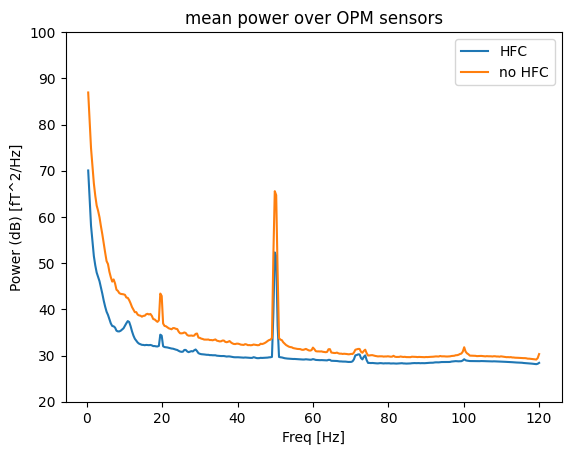

In [106]:
plt.plot(freqsc,np.mean(psd_dbc.T,axis=1), label='HFC')
plt.plot(freqs,np.mean(psd_db.T,axis=1),label='no HFC')
plt.legend();plt.ylim(20, 100);plt.xlabel('Freq [Hz]');
plt.ylabel('Power (dB) [fT^2/Hz]');plt.title('mean power over OPM sensors');

The reduction in power after HFC is now evident, particularly for the slower frequencies. The reduction is explained by artefacts being attenuated; most likely artefacts are due to head movements. Several of the spectral peaks are also reduces. However some peaks remain. This effect might system specific at the site.

## Calculate and plot the PSDs for the axes. 

The sensor power will now be considered separately for X, Y and Z axes. The seperation in sensors is mainly done to facility the later interpretation of the data. The Z axis correspond to magnetometers being most sensitive to field perpendicular to the brain surface. The respective sets of sensors will be selected based on their labels: 

In [107]:
OPMX = [item for item in rawHFC.ch_names if item.endswith("X")]
OPMY = [item for item in rawHFC.ch_names if item.endswith("Y")]
OPMZ = [item for item in rawHFC.ch_names if item.endswith("Z") and not item.startswith("BNC")]

Compute PSD for each X,Y and Z directions. This will be done using a time window of 1500 points resulting in a 0.5 Hz spectral resolution.

In [108]:
n_fft = 1500
raw_PSDX = rawHFC.compute_psd(method="welch", fmin=5, fmax=120, picks=OPMX, n_fft=n_fft, n_overlap=int(n_fft/2))
raw_PSDY = rawHFC.compute_psd(method="welch", fmin=5, fmax=120, picks=OPMY, n_fft=n_fft, n_overlap=int(n_fft/2))
raw_PSDZ = rawHFC.compute_psd(method="welch", fmin=5, fmax=120, picks=OPMZ, n_fft=n_fft, n_overlap=int(n_fft/2))


psdsX = raw_PSDX.get_data() # units are in T^2/Hz
freqsX = raw_PSDX.freqs 
psd_dbX = 10 * np.log10(psdsX * 1e30)  # Ref power: 1fT^2=1e-30T^2           
average_powerX = np.mean(psd_dbX, axis=1)

psdsY = raw_PSDY.get_data() # units are in T^2/Hz
freqsY = raw_PSDY.freqs 
psd_dbY = 10 * np.log10(psdsY * 1e30)  # Ref power: 1fT^2=1e-30T^2           
average_powerY = np.mean(psd_dbY, axis=1)

psdsZ = raw_PSDZ.get_data() # units are in T^2/Hz
freqsZ = raw_PSDZ.freqs 
psd_dbZ = 10 * np.log10(psdsZ * 1e30)  # Ref power: 1fT^2=1e-30T^2           
average_powerZ = np.mean(psd_dbZ, axis=1)

Effective window size : 2.000 (s)
Effective window size : 2.000 (s)
Effective window size : 2.000 (s)


To plot the result using the commands 

Text(0.5, 1.0, 'axis Z')

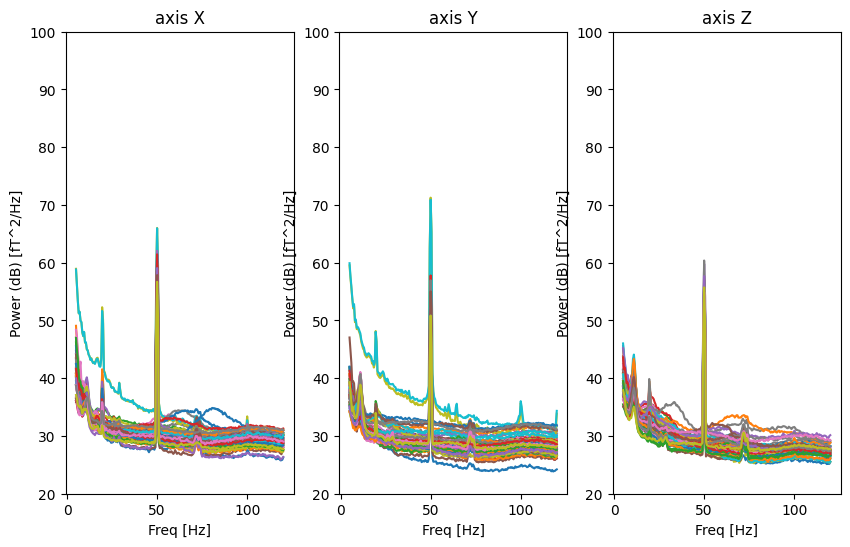

In [109]:
plt.figure(figsize=(10, 6))

plt.subplot(1,3,1)
plt.plot(freqsX,psd_dbX.T);plt.ylim(20, 100);plt.xlabel('Freq [Hz]');plt.ylabel('Power (dB) [fT^2/Hz]');plt.title('axis X')

plt.subplot(1,3,2)
plt.plot(freqsY,psd_dbY.T);plt.ylim(20, 100);plt.xlabel('Freq [Hz]');plt.ylabel('Power (dB) [fT^2/Hz]');plt.title('axis Y')

plt.subplot(1,3,3)
plt.plot(freqsY,psd_dbZ.T);plt.ylim(20, 100);plt.xlabel('Freq [Hz]');plt.ylabel('Power (dB) [fT^2/Hz]');plt.title('axis Z')

As can be overserved, the spectra looks reasonable and there are no obvious outliers in the 0 to 50 Hz range. Importantly, the Z-axes sensors are also the ones with the least stray sensors.  

Note the large artefacts every ~300 s. They occur at the breaks between the blocks and are probably due to head movements as the partipant is stretching and repositioning. 

The artifacts are now clearly reduced showing the utility of the HFC. These artifacts prior to the HFC were likely due to the participant moving within room. Despite the shielding, there will be recidual field remaining that procudes a signal when the sensors are moving within the recidual field. 

The power over a wide frequency range is reduced following HFC. This becomes more evident when considering the spectra averaged over sensors:

The reduction in power after HFC is now evident, particularly for the slower frequencies. The reduction is explained by artefacts being attenuated; most likely artefacts move head movements. 

#### Store the filtered data within the derivatives folder of the BIDS directory.

In [110]:
rawHFC.save(deriv_file_1, overwrite=True) 

Overwriting existing file.
Writing /Users/o.jensen@bham.ac.uk/Data/CercaOxf2/Experiment/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
Overwriting existing file.
Closing /Users/o.jensen@bham.ac.uk/Data/CercaOxf2/Experiment/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
[done]


[PosixPath('/Users/o.jensen@bham.ac.uk/Data/CercaOxf2/Experiment/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif')]

## Preregistration and Publication

The raw data is subjected to homogeneous field correction (HFC) which is the most important step of the pre-processing stage. The HFC assumes the external interference as a homogeneous field and attempts to separate the signal from the interference. We recommend using the homogeneous field correction which is able to work on low order data. HFC targets interference from distant magnetic sources. Such sources produce nearly uniform magnetic fields across all sensors, unlike brain signals, which vary with sensor position. HFC works by estimating this homogeneous field by finding the best-fit constant field vector across the sensor array at each time point and subtracting it from each sensor’s data. This removes spatially constant noise while preserving the local field variations generated by the brain sources.

## References

[1] Tierney, T.M., Alexander, N., Mellor, S., Holmes, N., Seymour, R., O'Neill, G.C., Maguire, E.A., & Barnes, G.R. (2021) *Modelling optically pumped magnetometer interference in MEG as a spatially homogeneous magnetic field.* Neuroimage. 244:118484. https://doi.org/10.1016/j.neuroimage.2021.118484. 
